# Silver Commodity Price Forecasting 

In [1]:
# Install once if needed:
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost tensorflow arch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Libraries loaded")
print("TensorFlow:", tf.__version__)

Libraries loaded
TensorFlow: 2.18.0


## STEP 1: Data Loading - 5 Files

In [2]:
daily = pd.read_csv("silver_daily_ohlcv_2000_2025.csv", parse_dates=["Date"])
macro = pd.read_csv("silver_macroeconomic_monthly.csv", parse_dates=["Date"])
sent = pd.read_csv("silver_sentiment_weekly.csv", parse_dates=["Week_Ending"])
supply = pd.read_csv("silver_supply_demand_annual.csv")
futures = pd.read_csv("silver_futures_contracts.csv", parse_dates=["Trade_Date"])

print(f"Daily: {daily.shape}, Macro: {macro.shape}, Sent: {sent.shape}")
print(f"Supply: {supply.shape}, Futures: {futures.shape}")
daily.head()

Daily: (6783, 13), Macro: (312, 19), Sent: (1043, 16)
Supply: (26, 20), Futures: (27390, 11)


,Date,Open,High,Low,Close,Adj_Close,Volume,VWAP,Returns_Pct,Log_Returns,Dollar_Change,Intraday_Range,Intraday_Range_Pct
0,2000-01-03,5.1962,5.1962,5.1884,5.1910,5.1910,36286,5.1919,-0.1729,-0.001731,-0.0090,0.0078,0.1511
1,2000-01-04,5.1084,5.1084,5.0848,5.0980,5.0980,35819,5.0971,-1.7916,-0.018079,-0.0930,0.0236,0.4649
2,2000-01-05,5.1388,5.1464,5.1388,5.1412,5.1412,38844,5.1421,0.8480,0.008444,0.0432,0.0076,0.1472
3,2000-01-06,5.2123,5.2291,5.2123,5.2239,5.2239,24445,5.2218,1.6076,0.015948,0.0826,0.0168,0.3225
4,2000-01-07,5.2766,5.2832,5.2766,5.2779,5.2779,40020,5.2792,1.0344,0.010291,0.0540,0.0066,0.1251


## STEP 2: Build Master Dataset

In [3]:
daily = daily.sort_values("Date").copy()
macro = macro.sort_values("Date").copy()
sent = sent.sort_values("Week_Ending").copy()

daily["Year"] = daily["Date"].dt.year
macro["Year"] = macro["Date"].dt.year

master = pd.merge_asof(
    daily,
    macro,
    left_on="Date",
    right_on="Date",
    direction="backward",
    suffixes=("", "_macro")
)

master = pd.merge(
    master,
    supply,
    on="Year",
    how="left"
)

master = pd.merge_asof(
    master.sort_values("Date"),
    sent,
    left_on="Date",
    right_on="Week_Ending",
    direction="backward"
)


master = master.sort_values("Date").reset_index(drop=True)

print("Master shape:", master.shape)
print("Date range:", master["Date"].min(), "to", master["Date"].max())
master[["Date", "Close", "Gold_Price_USD", "DXY_Index", "VIX_Index"]].tail()

Master shape: (6783, 68)
Date range: 2000-01-03 00:00:00 to 2025-12-31 00:00:00


,Date,Close,Gold_Price_USD,DXY_Index,VIX_Index
6778,2025-12-25,37.4841,2389.73,94.76,12.92
6779,2025-12-26,37.7450,2389.73,94.76,12.92
6780,2025-12-29,38.6309,2389.73,94.76,12.92
6781,2025-12-30,37.1281,2389.73,94.76,12.92
6782,2025-12-31,36.9662,2389.73,94.76,12.92


## STEP 3: Feature Engineering - Leakage Safe

In [4]:
master["MA_20"] = master["Close"].rolling(20).mean().shift(1)
master["MA_50"] = master["Close"].rolling(50).mean().shift(1)
master["Volatility_20D"] = master["Returns_Pct"].rolling(20).std().shift(1)
master["Gold_Silver_Ratio"] = (master["Gold_Price_USD"] / master["Close"]).shift(1)

master["Rolling_Max"] = master["Close"].cummax().shift(1)
master["Drawdown"] = (master["Close"].shift(1) - master["Rolling_Max"]) / master["Rolling_Max"]

lag_cols = [
    "Gold_Price_USD", "DXY_Index", "VIX_Index",
    "US_10Y_Yield", "CFTC_NonCommercial_Net"
]
for col in lag_cols:
    if col in master.columns:
        master[f"{col}_Lag1"] = master[col].shift(1)

master["Target_Close"] = master["Close"]

print("Leakage-safe features created")
master[["Date", "Close", "MA_20", "MA_50", "Volatility_20D", "Drawdown"]].tail()

Leakage-safe features created


,Date,Close,MA_20,MA_50,Volatility_20D,Drawdown
6778,2025-12-25,37.4841,34.764455,34.842044,1.601086,-0.240512
6779,2025-12-26,37.7450,34.904535,34.904456,1.549921,-0.227718
6780,2025-12-29,38.6309,35.113665,34.973584,1.293367,-0.222343
6781,2025-12-30,37.1281,35.365680,35.058186,1.344127,-0.204091
6782,2025-12-31,36.9662,35.526965,35.101968,1.690205,-0.235053


## STEP 4: Risk Analytics - VaR & GARCH

In [5]:
var_95 = master["Log_Returns"].dropna().quantile(0.05)
print(f"Historical 95% VaR: {var_95:.2%}")
print(f"Interpretation: on a ₹100 position, the historical 5% return quantile is about ₹{abs(var_95)*100:.2f}.")

try:
    from arch import arch_model

    returns = master["Log_Returns"].dropna() * 100
    am = arch_model(returns, vol="Garch", p=1, q=1)
    res = am.fit(disp="off")
    print(res.summary().tables[0])

    forecast = res.forecast(horizon=30)
    print(
        "Average next-30-period conditional variance forecast:",
        float(forecast.variance.iloc[-1].mean())
    )
except ImportError:
    print("arch is not installed. Run: pip install arch")

Historical 95% VaR: -2.97%
Interpretation: on a ₹100 position, the historical 5% return quantile is about ₹2.97.
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -13343.8
Distribution:                  Normal   AIC:                           26695.6
Method:            Maximum Likelihood   BIC:                           26722.9
                                        No. Observations:                 6783
Date:                Thu, Sep 24 2026   Df Residuals:                     6782
Time:                        20:34:28   Df Model:                            1
Average next-30-period conditional variance forecast: 2.7298325824620164


## STEP 5: Time-Series Train / Validation / Test Split

In [6]:
feature_cols = [
    "Gold_Price_USD_Lag1",
    "DXY_Index_Lag1",
    "VIX_Index_Lag1",
    "US_10Y_Yield_Lag1",
    "CFTC_NonCommercial_Net_Lag1",
    "MA_20",
    "MA_50",
    "Volatility_20D",
    "Gold_Silver_Ratio",
    "Drawdown"
]

feature_cols = [c for c in feature_cols if c in master.columns]

model_df = master[["Date", "Close"] + feature_cols].dropna().reset_index(drop=True)

n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("Rows:", n)
print("Train:", train_df["Date"].min(), "to", train_df["Date"].max(), len(train_df))
print("Validation:", val_df["Date"].min(), "to", val_df["Date"].max(), len(val_df))
print("Test:", test_df["Date"].min(), "to", test_df["Date"].max(), len(test_df))

Rows: 5213
Train: 2006-01-09 00:00:00 to 2020-01-02 00:00:00 3649
Validation: 2020-01-03 00:00:00 to 2023-01-02 00:00:00 782
Test: 2023-01-03 00:00:00 to 2025-12-31 00:00:00 782


## STEP 6: XGBoost 

In [7]:
X_train = train_df[feature_cols]
y_train = train_df["Close"]
X_val = val_df[feature_cols]
y_val = val_df["Close"]
X_test = test_df[feature_cols]
y_test = test_df["Close"]

xgb = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_val_pred = xgb.predict(X_val)
xgb_test_pred = xgb.predict(X_test)

def regression_metrics(actual, predicted):
    return {
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAE": mean_absolute_error(actual, predicted),
        "MAPE": mean_absolute_percentage_error(actual, predicted) * 100
    }

xgb_val_metrics = regression_metrics(y_val, xgb_val_pred)
xgb_test_metrics = regression_metrics(y_test, xgb_test_pred)

print("XGBoost Validation:", xgb_val_metrics)
print("XGBoost Test:", xgb_test_metrics)

XGBoost Validation: {'RMSE': np.float64(1.1790165685274419), 'MAE': 0.9069393561712007, 'MAPE': 4.004860059572435}
XGBoost Test: {'RMSE': np.float64(0.8737229342716039), 'MAE': 0.6965162380403875, 'MAPE': 2.4247932377070156}


## STEP 7: LSTM - Actual LSTM Model

In [8]:
close_values = model_df["Close"].values.reshape(-1, 1)

scaler = MinMaxScaler()
scaler.fit(train_df[["Close"]])
close_scaled = scaler.transform(close_values).flatten()

SEQ_LEN = 60

def make_lstm_sequences(values, dates, seq_len):
    X_seq, y_seq, d_seq = [], [], []
    for i in range(seq_len, len(values)):
        X_seq.append(values[i-seq_len:i])
        y_seq.append(values[i])
        d_seq.append(dates.iloc[i])
    return np.array(X_seq), np.array(y_seq), pd.Series(d_seq).reset_index(drop=True)

X_all_seq, y_all_seq, dates_all_seq = make_lstm_sequences(
    close_scaled,
    model_df["Date"],
    SEQ_LEN
)

train_mask = dates_all_seq < val_df["Date"].min()
val_mask = (dates_all_seq >= val_df["Date"].min()) & (dates_all_seq < test_df["Date"].min())
test_mask = dates_all_seq >= test_df["Date"].min()

X_lstm_train = X_all_seq[train_mask].reshape(-1, SEQ_LEN, 1)
y_lstm_train = y_all_seq[train_mask]

X_lstm_val = X_all_seq[val_mask].reshape(-1, SEQ_LEN, 1)
y_lstm_val = y_all_seq[val_mask]

X_lstm_test = X_all_seq[test_mask].reshape(-1, SEQ_LEN, 1)
y_lstm_test = y_all_seq[test_mask]

print("LSTM train:", X_lstm_train.shape)
print("LSTM validation:", X_lstm_val.shape)
print("LSTM test:", X_lstm_test.shape)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


LSTM train: (3589, 60, 1)
LSTM validation: (782, 60, 1)
LSTM test: (782, 60, 1)


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.20),
    LSTM(32),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(X_lstm_val, y_lstm_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


lstm_test_scaled = lstm_model.predict(X_lstm_test, verbose=0).reshape(-1, 1)
lstm_test_pred = scaler.inverse_transform(lstm_test_scaled).ravel()

lstm_val_scaled = lstm_model.predict(X_lstm_val, verbose=0).reshape(-1, 1)
lstm_val_pred = scaler.inverse_transform(lstm_val_scaled).ravel()

y_lstm_val_actual = scaler.inverse_transform(y_lstm_val.reshape(-1, 1)).ravel()
y_lstm_test_actual = scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).ravel()

lstm_val_metrics = regression_metrics(y_lstm_val_actual, lstm_val_pred)
lstm_test_metrics = regression_metrics(y_lstm_test_actual, lstm_test_pred)

print("LSTM Validation:", lstm_val_metrics)
print("LSTM Test:", lstm_test_metrics)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 31s 164ms/step - loss: 0.0238 - val_loss: 0.0011
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 23s 153ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 25s 218ms/step - loss: 0.0011 - val_loss: 8.5324e-04
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0011

## STEP 8: XGBoost + LSTM Ensemble - Validation Based Weight

In [ ]:
val_dates = val_df["Date"].reset_index(drop=True)
lstm_val_dates = dates_all_seq[val_mask].reset_index(drop=True)

val_compare = pd.DataFrame({
    "Date": val_dates,
    "Actual": y_val.reset_index(drop=True),
    "XGB": xgb_val_pred
})

lstm_val_compare = pd.DataFrame({
    "Date": lstm_val_dates,
    "LSTM": lstm_val_pred
})

val_compare = val_compare.merge(lstm_val_compare, on="Date", how="inner")

# Choose the ensemble weight on validation data, not on the test set.
best_weight = None
best_rmse = np.inf

for xgb_weight in np.arange(0.0, 1.01, 0.05):
    ensemble_val = (
        xgb_weight * val_compare["XGB"]
        + (1 - xgb_weight) * val_compare["LSTM"]
    )
    score = np.sqrt(mean_squared_error(val_compare["Actual"], ensemble_val))

    if score < best_rmse:
        best_rmse = score
        best_weight = xgb_weight

lstm_weight = 1 - best_weight

print(f"Selected validation weights -> XGBoost: {best_weight:.2f}, LSTM: {lstm_weight:.2f}")
print(f"Validation Ensemble RMSE: {best_rmse:.4f}")

Selected validation weights -> XGBoost: 0.00, LSTM: 1.00
Validation Ensemble RMSE: 0.5301


## STEP 9: Final Test Results

In [ ]:
test_dates = test_df["Date"].reset_index(drop=True)

test_compare = pd.DataFrame({
    "Date": test_dates,
    "Close": y_test.reset_index(drop=True),
    "XGB_Pred": xgb_test_pred
})

lstm_test_compare = pd.DataFrame({
    "Date": dates_all_seq[test_mask].reset_index(drop=True),
    "LSTM_Pred": lstm_test_pred
})

test_compare = test_compare.merge(lstm_test_compare, on="Date", how="inner")

test_compare["Ensemble_Pred"] = (
    best_weight * test_compare["XGB_Pred"]
    + lstm_weight * test_compare["LSTM_Pred"]
)

test_compare["Error_Pct"] = (
    abs(test_compare["Close"] - test_compare["Ensemble_Pred"])
    / test_compare["Close"] * 100
)

xgb_test_metrics = regression_metrics(
    test_compare["Close"], test_compare["XGB_Pred"]
)
lstm_test_metrics = regression_metrics(
    test_compare["Close"], test_compare["LSTM_Pred"]
)
ensemble_test_metrics = regression_metrics(
    test_compare["Close"], test_compare["Ensemble_Pred"]
)

results = pd.DataFrame([
    {"Model": "XGBoost", **xgb_test_metrics},
    {"Model": "LSTM", **lstm_test_metrics},
    {"Model": "XGBoost + LSTM Ensemble", **ensemble_test_metrics}
])

print(results)
test_compare.tail()

                     Model      RMSE       MAE      MAPE
0                  XGBoost  0.873723  0.696516  2.424793
1                     LSTM  0.951957  0.747456  2.443968
2  XGBoost + LSTM Ensemble  0.951957  0.747456  2.443968


,Date,Close,XGB_Pred,LSTM_Pred,Ensemble_Pred,Error_Pct
777,2025-12-25,37.4841,36.907799,35.390587,35.390587,5.585070
778,2025-12-26,37.7450,36.884148,35.673962,35.673962,5.486921
779,2025-12-29,38.6309,36.939064,35.979729,35.979729,6.862826
780,2025-12-30,37.1281,37.556717,36.526657,36.526657,1.619913
781,2025-12-31,36.9662,36.932293,36.232933,36.232933,1.983615


## STEP 10: Forecast Visualization

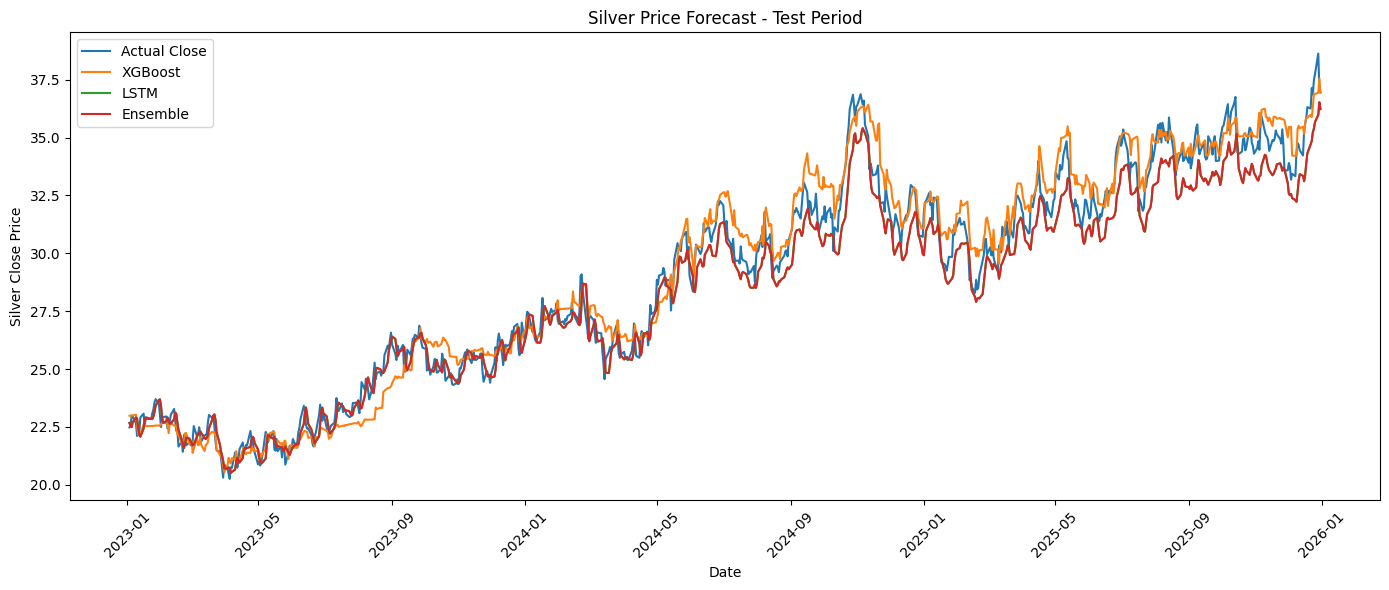

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(test_compare["Date"], test_compare["Close"], label="Actual Close")
plt.plot(test_compare["Date"], test_compare["XGB_Pred"], label="XGBoost")
plt.plot(test_compare["Date"], test_compare["LSTM_Pred"], label="LSTM")
plt.plot(test_compare["Date"], test_compare["Ensemble_Pred"], label="Ensemble")
plt.title("Silver Price Forecast - Test Period")
plt.xlabel("Date")
plt.ylabel("Silver Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## STEP 11: Power BI Export

In [ ]:
# Keep historical actuals plus model predictions where available.
powerbi_df = master[[
    "Date",
    "Close",
    "Gold_Price_USD",
    "DXY_Index",
    "VIX_Index",
    "MA_20",
    "MA_50",
    "Volatility_20D",
    "Drawdown"
]].copy()

powerbi_df = powerbi_df.merge(
    test_compare[[
        "Date",
        "XGB_Pred",
        "LSTM_Pred",
        "Ensemble_Pred",
        "Error_Pct"
    ]],
    on="Date",
    how="left"
)

powerbi_df["Forecast_Status"] = np.where(
    powerbi_df["Ensemble_Pred"].notna(),
    "Test Forecast",
    "Historical"
)

output_file = "silver_FINAL_POWERBI.csv"
powerbi_df.to_csv(output_file, index=False)

print(f"Power BI CSV created: {output_file}")
print("Rows:", len(powerbi_df))
print("Columns:", len(powerbi_df.columns))
powerbi_df.tail()

Power BI CSV created: silver_FINAL_POWERBI.csv
Rows: 6783
Columns: 14


,Date,Close,Gold_Price_USD,DXY_Index,VIX_Index,MA_20,MA_50,Volatility_20D,Drawdown,XGB_Pred,LSTM_Pred,Ensemble_Pred,Error_Pct,Forecast_Status
6778,2025-12-25,37.4841,2389.73,94.76,12.92,34.764455,34.842044,1.601086,-0.240512,36.907799,35.390587,35.390587,5.585070,Test Forecast
6779,2025-12-26,37.7450,2389.73,94.76,12.92,34.904535,34.904456,1.549921,-0.227718,36.884148,35.673962,35.673962,5.486921,Test Forecast
6780,2025-12-29,38.6309,2389.73,94.76,12.92,35.113665,34.973584,1.293367,-0.222343,36.939064,35.979729,35.979729,6.862826,Test Forecast
6781,2025-12-30,37.1281,2389.73,94.76,12.92,35.365680,35.058186,1.344127,-0.204091,37.556717,36.526657,36.526657,1.619913,Test Forecast
6782,2025-12-31,36.9662,2389.73,94.76,12.92,35.526965,35.101968,1.690205,-0.235053,36.932293,36.232933,36.232933,1.983615,Test Forecast


## STEP 12: Project Summary

### What was fixed
- Removed the fake `LSTM_Pred` moving-average substitute.
- Added a real LSTM model using 60-day sequences.
- Used chronological Train / Validation / Test splits.
- Scaled LSTM data using training data only.
- Selected ensemble weight on validation data.
- Evaluated the final ensemble only on unseen test data.
- Replaced the misleading percentage "Accuracy" with RMSE, MAE and MAPE.
- Exported a clean Power BI CSV.
